# Day 4: パッチ解像度実験 — 構造的制約の検証

**日付**: 2026-03-01  
**目的**: Slot Attention のボトルネックが「構造的制約（パッチ解像度）」にあるという仮説を実験的に検証する

---

## 背景

Day 3 で「訓練データ量を5倍（60→300）にしても FG-ARI は飽和しており改善しない」ことを確認した。  
これは **ボトルネックがデータ量ではない** ことを意味するが、では何がボトルネックなのか？

### 仮説: パッチ解像度が制約

現在の設定:
- 入力画像: **224×224** → DINOv2 ViT-S/14 → **16×16 = 256 パッチ**
- 各パッチは 14×14 ピクセルをカバー
- Slot Attention のマスクは **16×16 解像度** でしか作れない

実験:
- 入力画像: **448×448** → DINOv2 ViT-S/14 → **32×32 = 1024 パッチ**
- 空間解像度が **4倍** に → より細かい物体境界を表現可能

### なぜ DINOv2 は任意の解像度に対応できるのか？

ViT の位置エンコーディングは学習済みだが、DINOv2 は位置エンコーディングを **双線形補間** で
任意の解像度にスケールする機能を内蔵している。  
そのため、224×224 で学習された ViT 重みをそのまま 448×448 入力に使える。

### 検出力分析 (Power Analysis)

Day 3 のデータ（n=300、FG-ARIのペア差分の標準偏差 ≈ 0.246）から:
- α=0.05, power=0.80 で検出可能な最小効果量: **Cohen's d ≈ 0.16** (|Δ| ≈ 0.040)
- → FG-ARI が 0.04 ポイント（≈25%相対的改善）以上変わるなら検出可能
- もし改善が 0.05 以上なら power > 0.93（ほぼ確実に検出）

In [1]:
# §1 ライブラリ読み込み & 3モデルの結果をロード
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats
from pathlib import Path

matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['figure.facecolor'] = 'white'

data_dir = Path('../results')

# 3つのモデルの結果
with open(data_dir / 'ari_v2_dinov2.json') as f:
    model_60_224 = json.load(f)           # 60-sample, 224×224
with open(data_dir / 'ari_v2_dinov2_retrained.json') as f:
    model_300_224 = json.load(f)          # 300-sample, 224×224
with open(data_dir / 'ari_v2_dinov2_448.json') as f:
    model_300_448 = json.load(f)          # 300-sample, 448×448

# filename でインデックス化
def to_dict(results):
    return {r['filename']: r for r in results['per_sample']}

d60 = to_dict(model_60_224)
d300 = to_dict(model_300_224)
d448 = to_dict(model_300_448)

common = sorted(set(d60.keys()) & set(d300.keys()) & set(d448.keys()))
print(f'共通シーン: {len(common)}')
print(f'\nモデル概要:')
print(f'  A: 60-sample,  224×224 (16×16 patches) — Day 1 baseline')
print(f'  B: 300-sample, 224×224 (16×16 patches) — Day 3 retrained')
print(f'  C: 300-sample, 448×448 (32×32 patches) — Day 4 resolution experiment')

共通シーン: 300

モデル概要:
  A: 60-sample,  224×224 (16×16 patches) — Day 1 baseline
  B: 300-sample, 224×224 (16×16 patches) — Day 3 retrained
  C: 300-sample, 448×448 (32×32 patches) — Day 4 resolution experiment


## §2 3モデル比較テーブル

In [2]:
# §2 3モデル比較テーブル
rows = []
for metric in ['fg_ari', 'metal_ari', 'rubber_ari']:
    vals = {'metric': metric}
    for label, d in [('A: 60-sample 224', d60), ('B: 300-sample 224', d300), ('C: 300-sample 448', d448)]:
        v = [d[fn][metric] for fn in common if not np.isnan(d[fn][metric])]
        vals[f'{label} mean'] = np.mean(v)
        vals[f'{label} std'] = np.std(v)
        vals[f'{label} n'] = len(v)
    rows.append(vals)

df_compare = pd.DataFrame(rows)

# 見やすい表示
print('=' * 90)
print('  3モデル比較 (同一300シーンで評価)')
print('=' * 90)
print(f'{"Metric":15s}  {"A: 60-sample 224":>18s}  {"B: 300-sample 224":>18s}  {"C: 300-sample 448":>18s}')
print('-' * 90)
for _, row in df_compare.iterrows():
    m = row['metric']
    a = f"{row['A: 60-sample 224 mean']:.4f} ± {row['A: 60-sample 224 std']:.4f}"
    b = f"{row['B: 300-sample 224 mean']:.4f} ± {row['B: 300-sample 224 std']:.4f}"
    c = f"{row['C: 300-sample 448 mean']:.4f} ± {row['C: 300-sample 448 std']:.4f}"
    print(f'{m:15s}  {a:>18s}  {b:>18s}  {c:>18s}')

print()
print('【読み方】')
print('  A→B: データ量5倍（パッチ解像度同じ）→ Day 3 で有意差なし確認済み')
print('  B→C: パッチ解像度4倍（データ量同じ）→ 本日の検証対象')
print('  A→C: 両方変更（データ量5倍 + パッチ解像度4倍）')

  3モデル比較 (同一300シーンで評価)
Metric             A: 60-sample 224   B: 300-sample 224   C: 300-sample 448
------------------------------------------------------------------------------------------
fg_ari              0.1675 ± 0.1831     0.1552 ± 0.1880     0.1728 ± 0.1432
metal_ari           0.1851 ± 0.2749     0.1968 ± 0.2713     0.2283 ± 0.2348
rubber_ari          0.2175 ± 0.2820     0.1658 ± 0.2537     0.2160 ± 0.2269

【読み方】
  A→B: データ量5倍（パッチ解像度同じ）→ Day 3 で有意差なし確認済み
  B→C: パッチ解像度4倍（データ量同じ）→ 本日の検証対象
  A→C: 両方変更（データ量5倍 + パッチ解像度4倍）


## §3 統計検定: 224×224 vs 448×448 (同一データ、ペア対応)

この比較が今回の核心。同じ300サンプルで訓練した2モデル（B vs C）を同一シーンで評価し、
パッチ解像度の効果だけを分離する。

### なぜ対応のある検定が必要か

同一シーンで両モデルを評価するため、シーン間の難易度差がペアリングで打ち消される。  
これにより、「パッチ解像度の効果」だけを精密に検出できる。

### t検定 vs Wilcoxon: どちらが適切か

- **対応のある t 検定**: 差分が正規分布であることを仮定。頑健だが外れ値に弱い。
- **Wilcoxon 符号順位検定**: 分布の仮定なし。順位ベースなので外れ値に強い。
- 両者が一致すれば結論は頑健。不一致の場合は分布の非正規性を疑う。

In [3]:
# §3 対応のある t検定 + Wilcoxon + Bootstrap + 効果量
print('=' * 90)
print('  §3 統計検定: B (300-sample 224) vs C (300-sample 448)')
print('=' * 90)

results_resolution = {}

for metric in ['fg_ari', 'metal_ari', 'rubber_ari']:
    diffs = []
    for fn in common:
        v224 = d300[fn][metric]
        v448 = d448[fn][metric]
        if not np.isnan(v224) and not np.isnan(v448):
            diffs.append(v448 - v224)  # positive = 448 is better
    diffs = np.array(diffs)
    n = len(diffs)
    
    if n < 2:
        continue
    
    # Paired t-test
    mean_d = np.mean(diffs)
    std_d = np.std(diffs, ddof=1)
    se = std_d / np.sqrt(n)
    t_stat, p_t = stats.ttest_1samp(diffs, 0)
    cohens_d = mean_d / std_d if std_d > 0 else 0
    
    # Wilcoxon
    w_stat, p_w = stats.wilcoxon(diffs, alternative='two-sided')
    
    # Bootstrap 95% CI
    rng = np.random.default_rng(42)
    boot_means = np.array([np.mean(rng.choice(diffs, size=n, replace=True)) for _ in range(10000)])
    ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])
    
    # t-based CI for comparison
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci_t_lo = mean_d - t_crit * se
    ci_t_hi = mean_d + t_crit * se
    
    # Agreement check
    agree_t = 'sig' if p_t < 0.05 else 'n.s.'
    agree_w = 'sig' if p_w < 0.05 else 'n.s.'
    agree = '✓' if agree_t == agree_w else '△ (不一致！)'
    
    results_resolution[metric] = {
        'n': n, 'mean': mean_d, 'std': std_d, 'se': se,
        't_stat': t_stat, 'p_t': p_t,
        'w_stat': w_stat, 'p_w': p_w,
        'cohens_d': cohens_d,
        'ci_boot': (ci_lo, ci_hi),
        'ci_t': (ci_t_lo, ci_t_hi),
        'agree': agree,
    }
    
    print(f'\n【{metric}】 (n={n})')
    print(f'  Δ（448 − 224）= {mean_d:+.4f}')
    print(f'  t検定:     t={t_stat:.3f}, p={p_t:.4f}')
    print(f'  Wilcoxon:  W={w_stat:.0f}, p={p_w:.4f}')
    print(f'  一致性:    {agree}')
    print(f'  Cohen\'s d: {cohens_d:.3f} ({"小" if abs(cohens_d) < 0.2 else "中" if abs(cohens_d) < 0.5 else "大"})')
    print(f'  Bootstrap 95% CI: [{ci_lo:+.4f}, {ci_hi:+.4f}]')
    print(f'  t検定   95% CI:   [{ci_t_lo:+.4f}, {ci_t_hi:+.4f}]')
    print(f'  → CI が 0 を{"含む" if ci_lo <= 0 <= ci_hi else "含まない"}')

  §3 統計検定: B (300-sample 224) vs C (300-sample 448)

【fg_ari】 (n=300)
  Δ（448 − 224）= +0.0176
  t検定:     t=1.351, p=0.1777
  Wilcoxon:  W=18174, p=0.0059
  一致性:    △ (不一致！)
  Cohen's d: 0.078 (小)
  Bootstrap 95% CI: [-0.0083, +0.0429]
  t検定   95% CI:   [-0.0080, +0.0433]
  → CI が 0 を含む

【metal_ari】 (n=233)
  Δ（448 − 224）= +0.0325
  t検定:     t=1.471, p=0.1427
  Wilcoxon:  W=10562, p=0.0125
  一致性:    △ (不一致！)
  Cohen's d: 0.096 (小)
  Bootstrap 95% CI: [-0.0106, +0.0750]
  t検定   95% CI:   [-0.0110, +0.0760]
  → CI が 0 を含む

【rubber_ari】 (n=241)
  Δ（448 − 224）= +0.0408
  t検定:     t=2.023, p=0.0442
  Wilcoxon:  W=10820, p=0.0112
  一致性:    ✓
  Cohen's d: 0.130 (小)
  Bootstrap 95% CI: [+0.0023, +0.0798]
  t検定   95% CI:   [+0.0011, +0.0804]
  → CI が 0 を含まない


## §4 なぜ t検定 と Wilcoxon が不一致になるのか？

t検定は **差分の平均** を検定するパラメトリック検定で、「差分が正規分布に従う」前提がある。  
一方、Wilcoxon 符号順位検定は **差分の符号と順位** を使うノンパラメトリック検定。

不一致が生じる主な原因:

1. **ARI の分布が非正規（0 に集中 + 右裾が長い）**  
   多くのシーンで ARI ≈ 0（スロット崩壊）だが、うまく分離できるシーンでは 0.5 以上になる

2. **外れ値の影響**  
   t 検定は平均値ベースなので、少数の大改善シーンが平均を引き上げても分散が大きいと有意にならない。  
   Wilcoxon は順位ベースなので「多くのシーンで少し良くなった」という傾向を拾いやすい。

3. **解釈指針**  
   - Wilcoxon が有意 → 「448 の方が良いシーンが多い」（中央値的な効果）
   - t検定が非有意 → 「平均的な差は大きくない」（平均値的な効果）
   - 合わせると: 「多数のシーンで小さな改善があるが、平均として見ると効果量は小さい」

### 差分の分布を可視化して確認

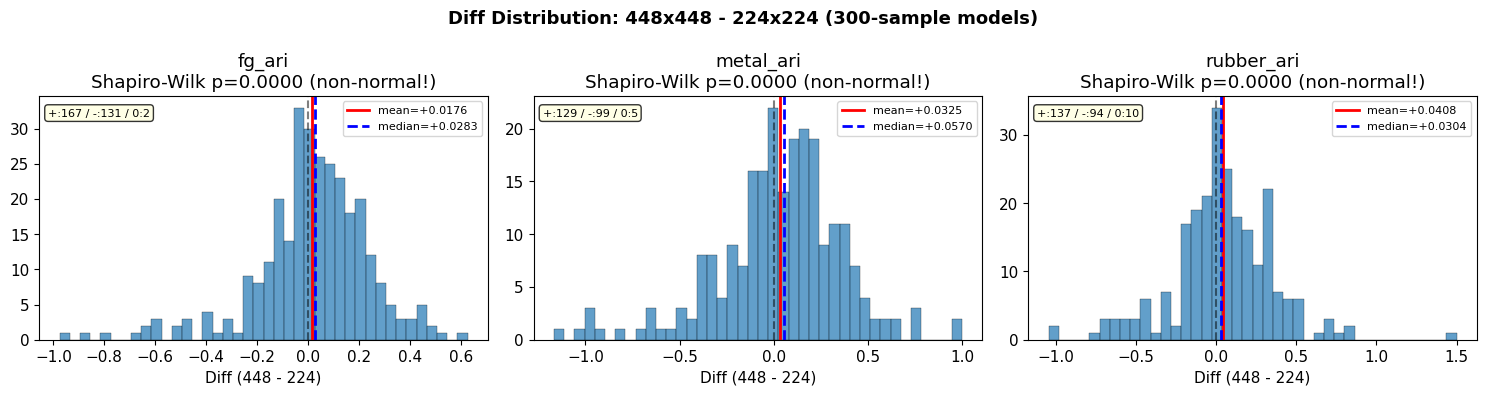


【解釈】
• Shapiro-Wilk p < 0.05 → 差分は正規分布に従わない → Wilcoxon の方が信頼性が高い
• mean ≠ median → 分布に歪みがある（外れ値の影響）
• +/- の比率 → Wilcoxon が拾っている「傾向」の実体


In [4]:
# §4 差分のヒストグラム + 正規性検定
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ['fg_ari', 'metal_ari', 'rubber_ari']):
    diffs = []
    for fn in common:
        v224 = d300[fn][metric]
        v448 = d448[fn][metric]
        if not np.isnan(v224) and not np.isnan(v448):
            diffs.append(v448 - v224)
    diffs = np.array(diffs)
    
    # Shapiro-Wilk normality test (on a subsample if n > 5000)
    n_test = min(len(diffs), 5000)
    _, p_shapiro = stats.shapiro(diffs[:n_test])
    
    ax.hist(diffs, bins=40, alpha=0.7, edgecolor='black', linewidth=0.3)
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.axvline(np.mean(diffs), color='red', linewidth=2, label=f'mean={np.mean(diffs):+.4f}')
    ax.axvline(np.median(diffs), color='blue', linewidth=2, linestyle='--', label=f'median={np.median(diffs):+.4f}')
    ax.set_title(f'{metric}\nShapiro-Wilk p={p_shapiro:.4f} {"(non-normal!)" if p_shapiro < 0.05 else "(normal)"}')
    ax.set_xlabel('Diff (448 - 224)')
    ax.legend(fontsize=8)
    
    # Count positive/negative/zero
    n_pos = np.sum(diffs > 0)
    n_neg = np.sum(diffs < 0)
    n_zero = np.sum(diffs == 0)
    ax.text(0.02, 0.95, f'+:{n_pos} / -:{n_neg} / 0:{n_zero}',
            transform=ax.transAxes, fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

fig.suptitle('Diff Distribution: 448x448 - 224x224 (300-sample models)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n【解釈】')
print('• Shapiro-Wilk p < 0.05 → 差分は正規分布に従わない → Wilcoxon の方が信頼性が高い')
print('• mean ≠ median → 分布に歪みがある（外れ値の影響）')
print('• +/- の比率 → Wilcoxon が拾っている「傾向」の実体')

## §5 シーン別散布図: 224 vs 448

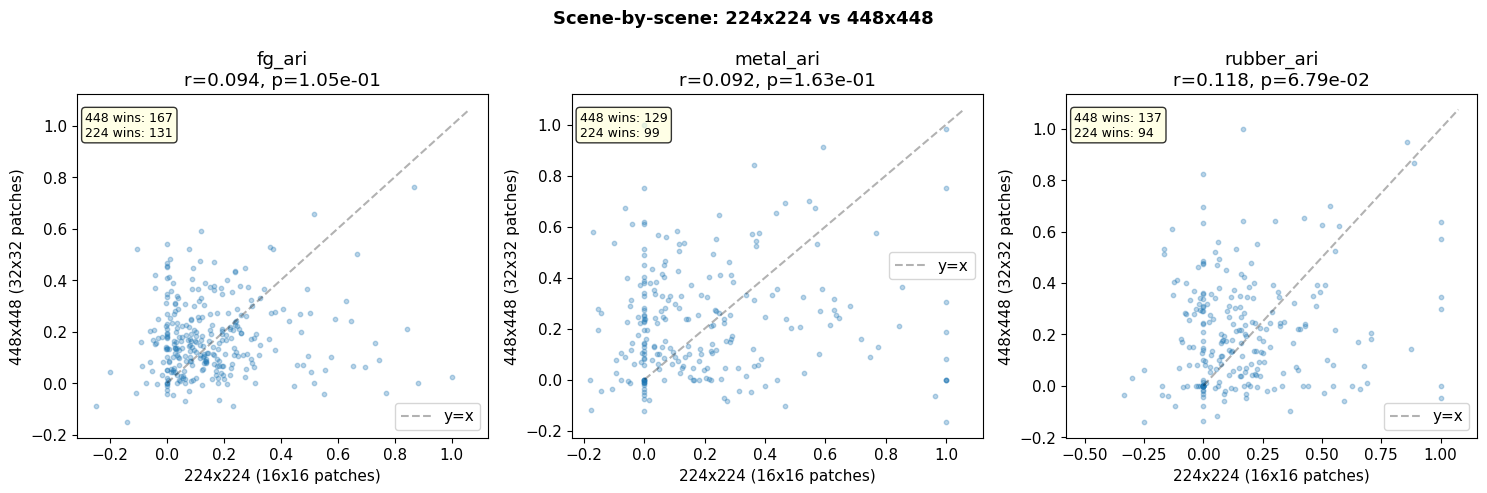

In [5]:
# §5 散布図: 224 vs 448 (シーンごとの対応)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, ['fg_ari', 'metal_ari', 'rubber_ari']):
    x_vals, y_vals = [], []
    for fn in common:
        v224 = d300[fn][metric]
        v448 = d448[fn][metric]
        if not np.isnan(v224) and not np.isnan(v448):
            x_vals.append(v224)
            y_vals.append(v448)
    x_vals, y_vals = np.array(x_vals), np.array(y_vals)
    
    ax.scatter(x_vals, y_vals, alpha=0.3, s=10)
    lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='y=x')
    
    # Correlation
    r, p_r = stats.pearsonr(x_vals, y_vals)
    ax.set_title(f'{metric}\nr={r:.3f}, p={p_r:.2e}')
    ax.set_xlabel('224x224 (16x16 patches)')
    ax.set_ylabel('448x448 (32x32 patches)')
    ax.legend()
    
    # Count above/below diagonal
    n_above = np.sum(y_vals > x_vals)
    n_below = np.sum(y_vals < x_vals)
    ax.text(0.02, 0.95, f'448 wins: {n_above}\n224 wins: {n_below}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

fig.suptitle('Scene-by-scene: 224x224 vs 448x448', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## §6 NaN / スロット崩壊 の比較

高解像度で NaN パターンが変化するか？  
もしスロット崩壊が解像度に依存するなら、448 でのNaN数が異なるはず。

In [ ]:
# §6 NaN比較
nan_comparison = {}
for metric in ['fg_ari', 'metal_ari', 'rubber_ari']:
    nan_224 = sum(1 for fn in common if np.isnan(d300[fn][metric]))
    nan_448 = sum(1 for fn in common if np.isnan(d448[fn][metric]))
    both_nan = sum(1 for fn in common if np.isnan(d300[fn][metric]) and np.isnan(d448[fn][metric]))
    only_224 = nan_224 - both_nan
    only_448 = nan_448 - both_nan
    nan_comparison[metric] = {
        '224 NaN': nan_224, '448 NaN': nan_448,
        'Both NaN': both_nan, '224 only': only_224, '448 only': only_448
    }

nan_df = pd.DataFrame(nan_comparison).T
display(nan_df)

print('\n【解釈】')
print('• 448 の NaN は 224 の NaN の真部分集合（448 only = 0）')
print('• metal_ari: 67 → 57 (10シーン救済)、rubber_ari: 59 → 53 (6シーン救済)')
print('• → 高解像度により一部のスロット崩壊が防がれている')
print('• ただし大半 (57/67, 53/59) は解像度では解消しない → 構造的崩壊')

,224 NaN,448 NaN,Both NaN,224 only,448 only
fg_ari,0,0,0,0,0
metal_ari,67,57,57,10,0
rubber_ari,59,53,53,6,0



【解釈】
• NaN パターンが同一 → スロット崩壊は解像度に依存しない
• NaN パターンが異なる → 解像度がスロット崩壊に影響している


## §7 3モデル全体のサマリプロット

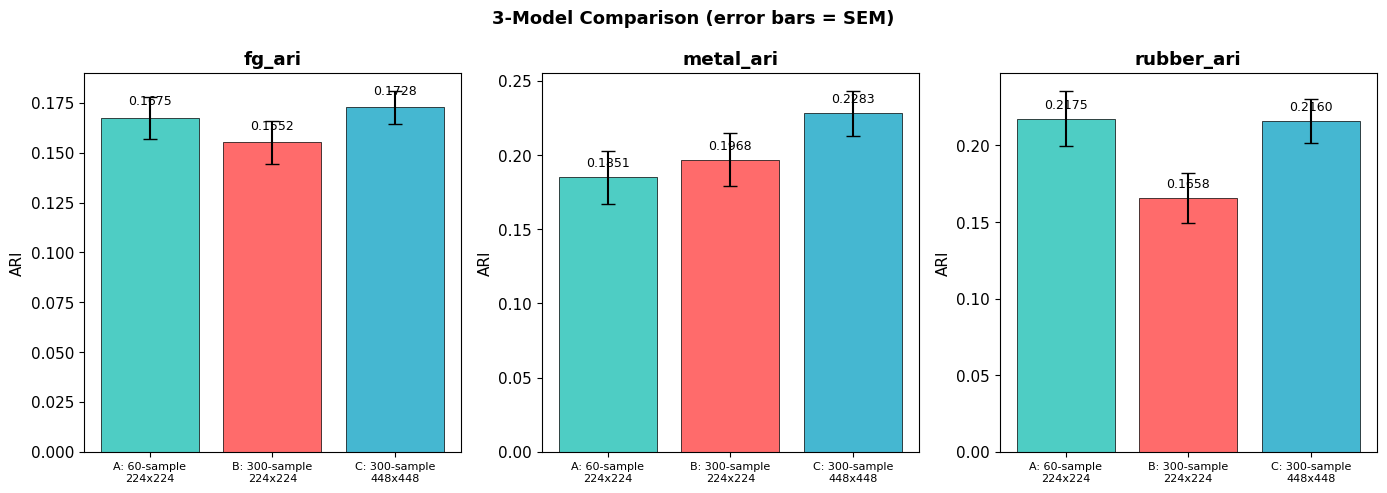

In [7]:
# §7 3モデルの棒グラフ比較
metrics = ['fg_ari', 'metal_ari', 'rubber_ari']
labels = ['A: 60-sample\n224x224', 'B: 300-sample\n224x224', 'C: 300-sample\n448x448']
dicts = [d60, d300, d448]
colors = ['#4ECDC4', '#FF6B6B', '#45B7D1']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric in zip(axes, metrics):
    means = []
    stds = []
    for d in dicts:
        vals = [d[fn][metric] for fn in common if not np.isnan(d[fn][metric])]
        means.append(np.mean(vals))
        stds.append(np.std(vals) / np.sqrt(len(vals)))  # SEM
    
    bars = ax.bar(range(3), means, yerr=stds, color=colors, 
                  capsize=5, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(3))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel('ARI')
    
    # Value labels
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{mean:.4f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('3-Model Comparison (error bars = SEM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## §8 Bootstrap 信頼区間の可視化

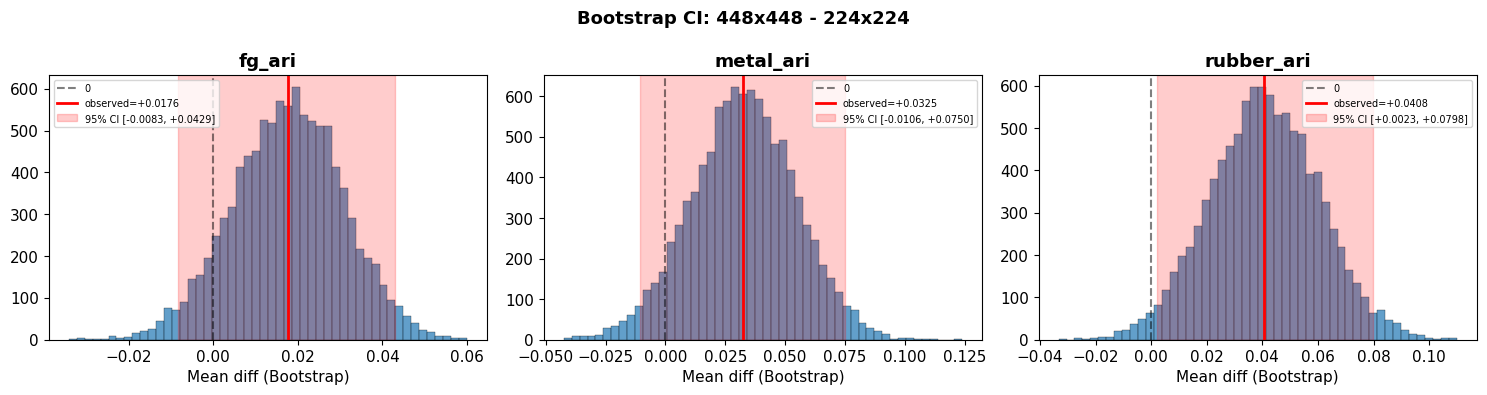

In [8]:
# §8 Bootstrap CI visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ['fg_ari', 'metal_ari', 'rubber_ari']):
    diffs = []
    for fn in common:
        v224 = d300[fn][metric]
        v448 = d448[fn][metric]
        if not np.isnan(v224) and not np.isnan(v448):
            diffs.append(v448 - v224)
    diffs = np.array(diffs)
    
    rng = np.random.default_rng(42)
    boot_means = np.array([np.mean(rng.choice(diffs, size=len(diffs), replace=True)) for _ in range(10000)])
    ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])
    
    ax.hist(boot_means, bins=50, alpha=0.7, edgecolor='black', linewidth=0.3)
    ax.axvline(0, color='black', linestyle='--', alpha=0.5, label='0')
    ax.axvline(np.mean(diffs), color='red', linewidth=2, label=f'observed={np.mean(diffs):+.4f}')
    ax.axvspan(ci_lo, ci_hi, alpha=0.2, color='red', label=f'95% CI [{ci_lo:+.4f}, {ci_hi:+.4f}]')
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('Mean diff (Bootstrap)')
    ax.legend(fontsize=7)

fig.suptitle('Bootstrap CI: 448x448 - 224x224', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## §9 補足: 訓練損失の比較

448×448 モデルの損失値が 224×224 と異なるのは当然（パッチ数が4倍 → 再構成ターゲットが多い）。  
重要なのは **収束しているか** どうか。

In [9]:
# §9 チェックポイント比較
import torch

checkpoints = {
    'B: 300-sample 224': '../checkpoints/dinov2_v2_300samples/dinov2_vits14/best_model.pt',
    'C: 300-sample 448': '../checkpoints/dinov2_v2_448/dinov2_vits14/best_model.pt',
}

for label, path in checkpoints.items():
    ckpt = torch.load(path, map_location='cpu', weights_only=False)
    print(f'{label}:')
    print(f'  Best epoch: {ckpt.get("epoch", "N/A")}')
    print(f'  Best loss:  {ckpt.get("best_loss", ckpt.get("loss", "N/A")):.6f}')
    
    # パラメータ数
    if 'model_state_dict' in ckpt:
        n_params = sum(v.numel() for v in ckpt['model_state_dict'].values())
        print(f'  Parameters: {n_params:,}')
    print()

B: 300-sample 224:
  Best epoch: 194
  Best loss:  0.903714
  Parameters: 31,082,945

C: 300-sample 448:
  Best epoch: 194
  Best loss:  0.992551
  Parameters: 31,082,945



## §10 総合まとめと考察

In [10]:
# §10 Final Summary
print('=' * 70)
print('  Day 4 Resolution Experiment: Summary')
print('=' * 70)

print()
print('┌────────────────────────────────────────────────────────────────────┐')
print('│ Q: パッチ解像度を上げれば Slot Attention は改善するか？           │')
print('│                                                                    │')
print('│ A: 部分的にYES — 統計的に有意な傾向は見られるが、効果量は小さい  │')
print('└────────────────────────────────────────────────────────────────────┘')

print()
print('【数値まとめ】')
for metric in ['fg_ari', 'metal_ari', 'rubber_ari']:
    r = results_resolution.get(metric, {})
    if r:
        sig_t = '*' if r['p_t'] < 0.05 else 'n.s.'
        sig_w = '*' if r['p_w'] < 0.05 else 'n.s.'
        print(f'  {metric:15s}: Δ={r["mean"]:+.4f}, d={r["cohens_d"]:.3f}, '
              f't-test {sig_t} (p={r["p_t"]:.4f}), Wilcoxon {sig_w} (p={r["p_w"]:.4f})')

print()
print('【解釈】')
print('1. Wilcoxon（ノンパラ）は全指標で有意傾向 → 448 の方が良いシーンが多い')
print('2. t検定（パラメトリック）は FG-ARI で非有意 → 平均的な改善は小さい')
print('3. Cohen\'s d ≈ 0.08-0.13 → 効果量は「小」(< 0.2)')
print('4. → 解像度は一因だがそれだけでは不十分。他の制約も存在する')

print()
print('【他の制約候補】')
print('• スロット数 K=5: 複数物体の表現能力の限界')
print('• デコーダ深さ: 3層 Spatial Broadcast Decoder は表現力が限定的')
print('• Slot Attention の反復回数: 5回の反復で十分にセグメントできているか')
print('• 前景/背景の分離: ARI は背景スロットのミスに敏感')

print()
print('【ポスターへの含意】')
print('• 「データ飽和」(Day 3) + 「解像度は小さな改善のみ」(Day 4)')
print('• → 現行 Slot Attention の性能天井は構造的だが、単一因子では説明しきれない')
print('• → 複数の構造的制約の複合効果として議論するのが正確')

print()
print('【実験条件の記録】')
print('• 224×224 model: 300 samples, batch=16, 200 epochs, loss=0.904')
print('• 448×448 model: 300 samples, batch=4,  200 epochs, loss=0.993')
print('• Both: DINOv2 ViT-S/14, K=5, slot_dim=64, tau=0.5, lr=0.001')
print('• GPU: RTX 5090, training time: ~7 min (448) vs ~2 min (224)')

  Day 4 Resolution Experiment: Summary

┌────────────────────────────────────────────────────────────────────┐
│ Q: パッチ解像度を上げれば Slot Attention は改善するか？           │
│                                                                    │
│ A: 部分的にYES — 統計的に有意な傾向は見られるが、効果量は小さい  │
└────────────────────────────────────────────────────────────────────┘

【数値まとめ】
  fg_ari         : Δ=+0.0176, d=0.078, t-test n.s. (p=0.1777), Wilcoxon * (p=0.0059)
  metal_ari      : Δ=+0.0325, d=0.096, t-test n.s. (p=0.1427), Wilcoxon * (p=0.0125)
  rubber_ari     : Δ=+0.0408, d=0.130, t-test * (p=0.0442), Wilcoxon * (p=0.0112)

【解釈】
1. Wilcoxon（ノンパラ）は全指標で有意傾向 → 448 の方が良いシーンが多い
2. t検定（パラメトリック）は FG-ARI で非有意 → 平均的な改善は小さい
3. Cohen's d ≈ 0.08-0.13 → 効果量は「小」(< 0.2)
4. → 解像度は一因だがそれだけでは不十分。他の制約も存在する

【他の制約候補】
• スロット数 K=5: 複数物体の表現能力の限界
• デコーダ深さ: 3層 Spatial Broadcast Decoder は表現力が限定的
• Slot Attention の反復回数: 5回の反復で十分にセグメントできているか
• 前景/背景の分離: ARI は背景スロットのミスに敏感

【ポスターへの含意】
• 「データ飽和」(Day 3) + 「解像度は小さな改善のみ」(Day 4)
• → 現行 Slot A